In [1]:
%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# RETAIL DEMAND & INVENTORY ANALYSIS
# Demand Forecasting Project
# Python 3.14
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

import sklearn
print(sklearn.__version__)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make relative paths work regardless of the notebook's current working directory.
PROJECT_DIR = Path.cwd()
while PROJECT_DIR != PROJECT_DIR.parent and not (PROJECT_DIR / "data" / "sales_data.csv").exists():
    PROJECT_DIR = PROJECT_DIR.parent

if not (PROJECT_DIR / "data" / "sales_data.csv").exists():
    raise FileNotFoundError("Could not find data/sales_data.csv from the current directory or its parents.")

os.chdir(PROJECT_DIR)
print("Project directory:", PROJECT_DIR)

1.9.0
Project directory: c:\Users\Admin\Desktop\DA projects\Retail, Inventory, Demand prediction


In [3]:
# ============================================================
# 1. LOAD DATA
# ============================================================

FILE_PATH = "data/sales_data.csv"

df = pd.read_csv(FILE_PATH)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

DATASET OVERVIEW
Shape: (76000, 16)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']

Data types:
Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition         str
Promotion               int64
Competitor Pricing    float64
Seasonality               str
Epidemic                int64
Demand                  int64
dtype: object

Missing values:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price            

In [4]:
# ============================================================
# 2. DATA CLEANING
# ============================================================

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

# Remove duplicates
df = df.drop_duplicates()

# Sort data
df = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

In [5]:
# ============================================================
# 3. BASIC DATA VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("DATE RANGE")
print("=" * 60)

print("Start:", df["Date"].min())
print("End:", df["Date"].max())
print("Number of days:", df["Date"].nunique())

print("\nStores:", df["Store ID"].nunique())
print("Products:", df["Product ID"].nunique())
print("Categories:", df["Category"].nunique())
print("Regions:", df["Region"].nunique())


DATE RANGE
Start: 2022-01-01 00:00:00
End: 2024-01-30 00:00:00
Number of days: 760

Stores: 5
Products: 20
Categories: 5
Regions: 4


In [6]:
# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

# Calendar features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Price difference versus competitor
df["Price Gap"] = df["Price"] - df["Competitor Pricing"]

# Inventory gap
df["Inventory Gap"] = df["Inventory Level"] - df["Demand"]

# Potential stockout risk
df["Stockout Risk"] = (
    df["Inventory Level"] < df["Demand"]
).astype(int)

# Inventory coverage ratio
df["Inventory Coverage"] = (
    df["Inventory Level"] / df["Demand"].replace(0, np.nan)
)

# Demand lag features
group = df.groupby(["Store ID", "Product ID"])["Demand"]

df["Demand_Lag_1"] = group.shift(1)
df["Demand_Lag_7"] = group.shift(7)
df["Demand_Lag_28"] = group.shift(28)

# Rolling demand
df["Demand_Rolling_7"] = (
    df.groupby(["Store ID", "Product ID"])["Demand"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["Demand_Rolling_28"] = (
    df.groupby(["Store ID", "Product ID"])["Demand"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

In [7]:
# ============================================================
# 5. CREATE CHART FOLDER
# ============================================================

os.makedirs("charts", exist_ok=True)

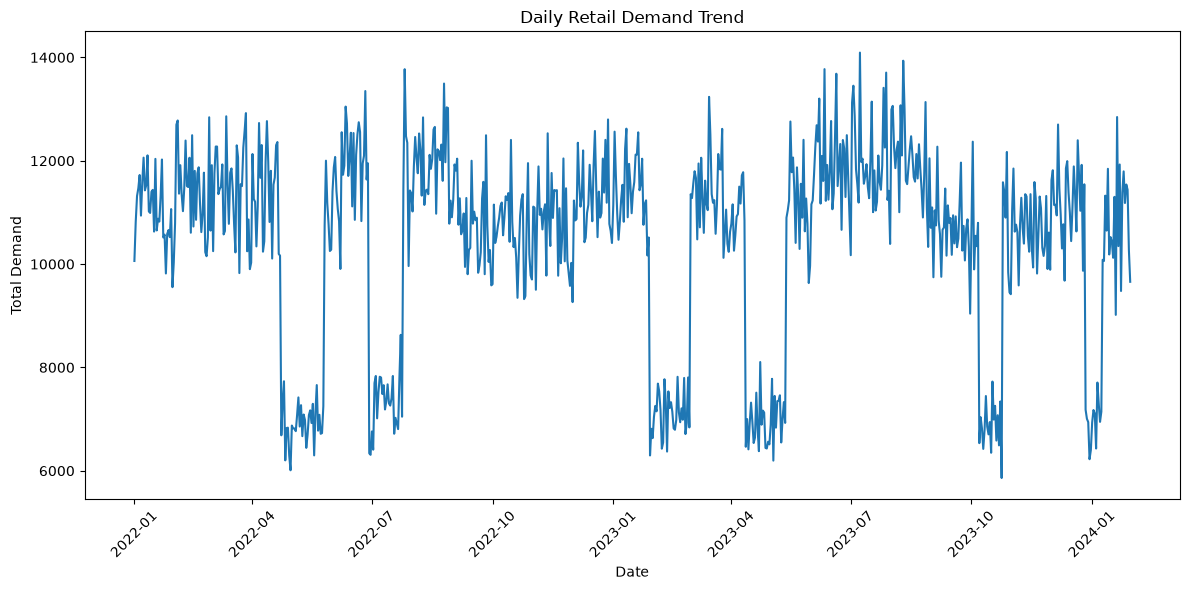

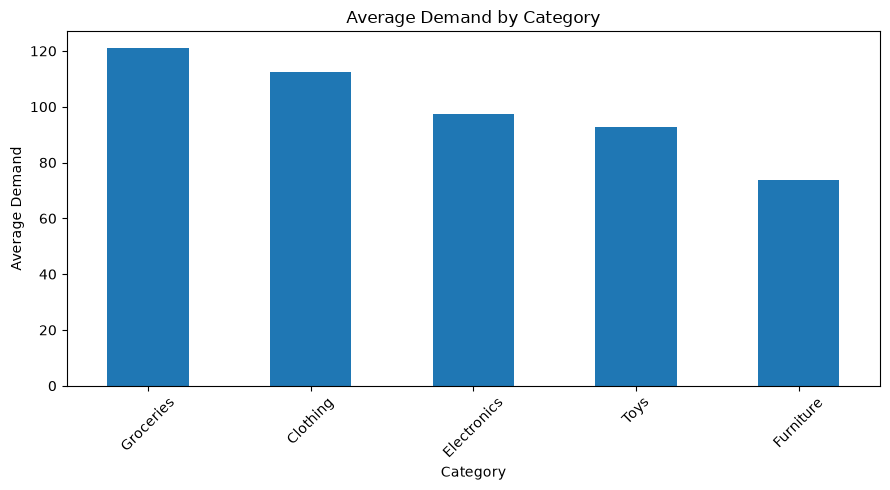

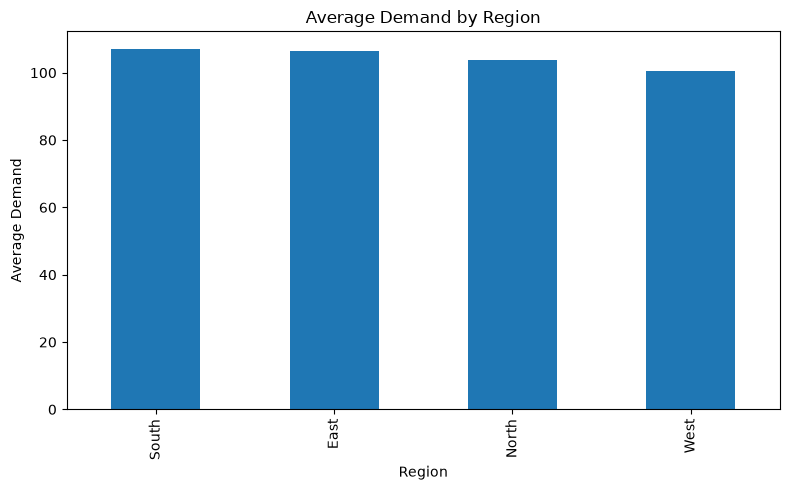

In [8]:
# ============================================================
# 6. RETAIL EDA
# ============================================================

# ------------------------------------------------------------
# Chart 1: Overall Demand Trend
# ------------------------------------------------------------

daily_demand = (
    df.groupby("Date")["Demand"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Demand"]
)

plt.title("Daily Retail Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("charts/01_daily_demand_trend.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# Chart 2: Demand by Category
# ------------------------------------------------------------

category_demand = (
    df.groupby("Category")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

category_demand.plot(kind="bar")

plt.title("Average Demand by Category")
plt.xlabel("Category")
plt.ylabel("Average Demand")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/02_demand_by_category.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# Chart 3: Demand by Region
# ------------------------------------------------------------

region_demand = (
    df.groupby("Region")["Demand"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

region_demand.plot(kind="bar")

plt.title("Average Demand by Region")
plt.xlabel("Region")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.savefig("charts/03_demand_by_region.png", dpi=150)
plt.show()

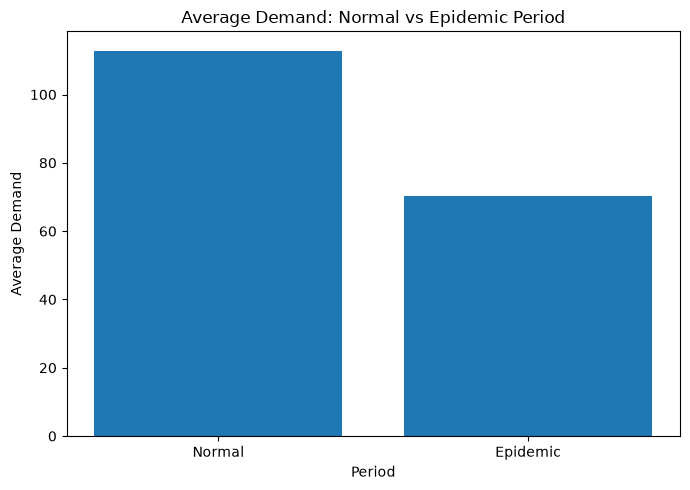

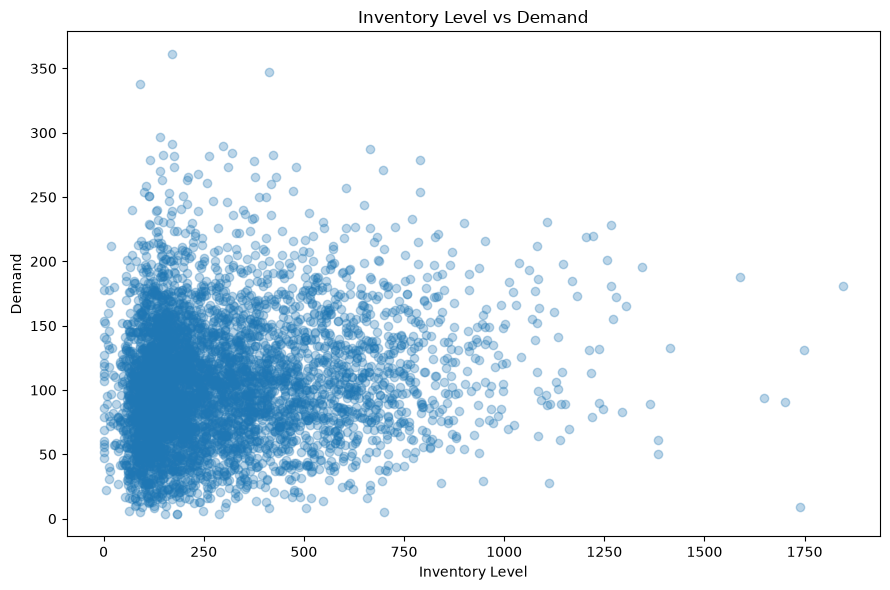

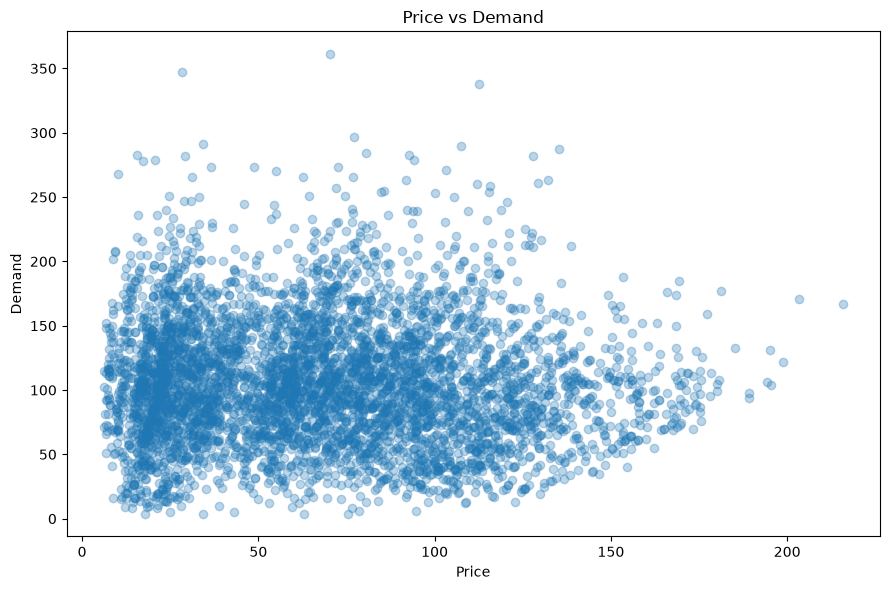

In [9]:
# ------------------------------------------------------------
# Chart 4: Epidemic vs Normal Period
# ------------------------------------------------------------

epidemic_demand = (
    df.groupby("Epidemic")["Demand"]
    .mean()
)

labels = ["Normal", "Epidemic"]

plt.figure(figsize=(7, 5))

plt.bar(labels, epidemic_demand.values)

plt.title("Average Demand: Normal vs Epidemic Period")
plt.xlabel("Period")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.savefig("charts/04_epidemic_demand.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# Chart 5: Inventory vs Demand
# ------------------------------------------------------------

sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(9, 6))

plt.scatter(
    sample_df["Inventory Level"],
    sample_df["Demand"],
    alpha=0.3
)

plt.title("Inventory Level vs Demand")
plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.tight_layout()
plt.savefig("charts/05_inventory_vs_demand.png", dpi=150)
plt.show()


# ------------------------------------------------------------
# Chart 6: Price vs Demand
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    sample_df["Price"],
    sample_df["Demand"],
    alpha=0.3
)

plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")

plt.tight_layout()
plt.savefig("charts/06_price_vs_demand.png", dpi=150)
plt.show()

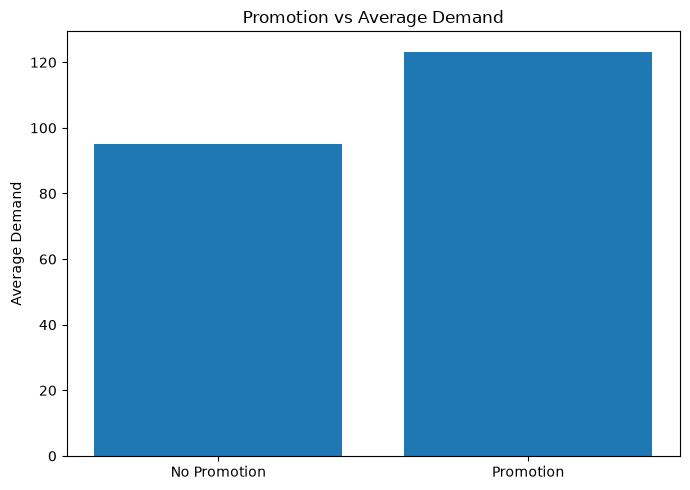


INVENTORY ANALYSIS
Overall stockout risk: 13.68%

Stockout risk by category:
Category
Clothing       19.424342
Toys           14.971805
Electronics    13.870614
Groceries      13.490132
Furniture       7.843567
Name: Stockout Risk, dtype: float64


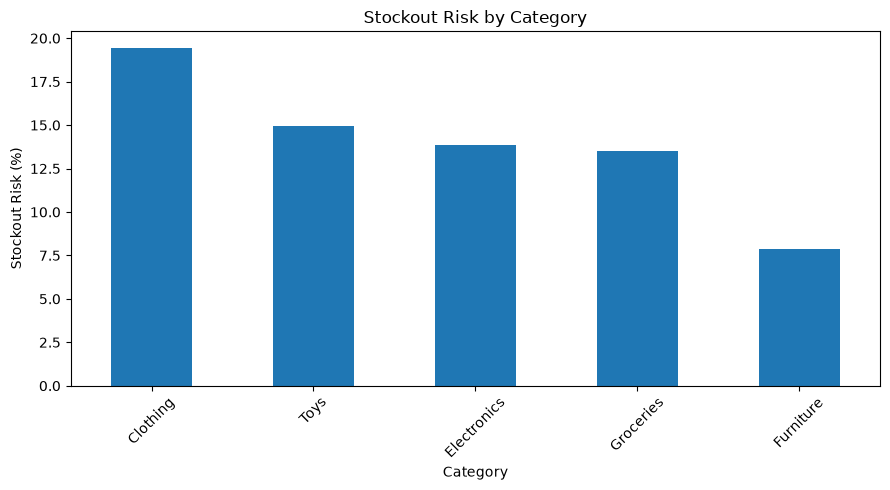


Top 10 products by total demand:
            Avg_Demand  Total_Demand  Avg_Inventory  Avg_Price  Stockout_Rate
Product ID                                                                   
P0009       118.506316        450324     272.303684  83.047739       0.185789
P0013       116.025000        440895     382.652632  44.303395       0.101579
P0004       115.396053        438505     320.350000  45.307184       0.121316
P0007       115.023421        437089     466.860000  35.674368       0.062105
P0002       112.066579        425853     285.830789  42.719934       0.141579
P0010       111.069474        422064     310.549474  66.468400       0.181842
P0001       109.591316        416447     331.758684  37.220403       0.096316
P0006       107.722368        409345     283.058421  46.914603       0.172105
P0005       107.520526        408578     392.904211  50.747358       0.109474
P0008       104.352105        396538     151.431316  67.067661       0.283947

CORRELATION WITH DEMAND
Deman

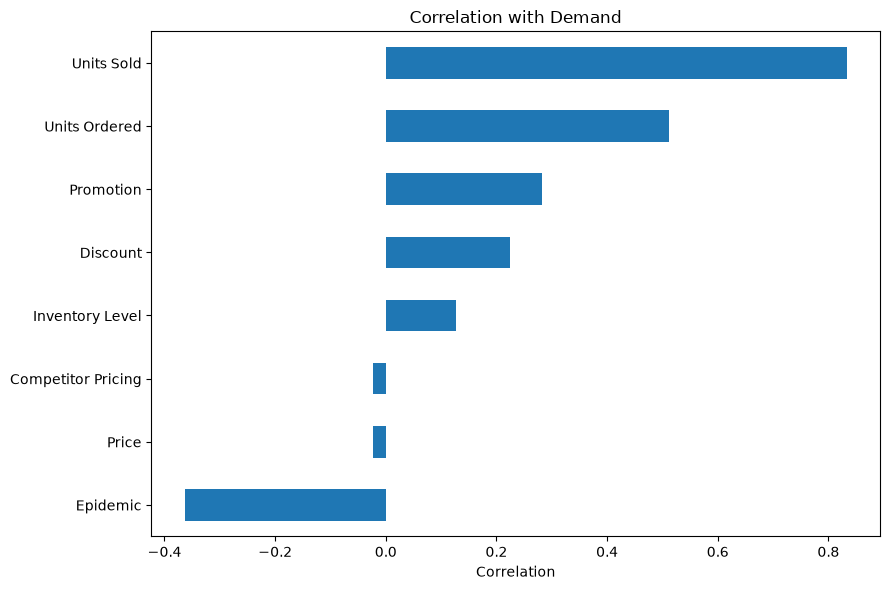

In [10]:
# ------------------------------------------------------------
# Chart 7: Promotion vs Demand
# ------------------------------------------------------------

promotion_demand = (
    df.groupby("Promotion")["Demand"]
    .mean()
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Promotion", "Promotion"],
    promotion_demand.values
)

plt.title("Promotion vs Average Demand")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.savefig("charts/07_promotion_demand.png", dpi=150)
plt.show()


# ============================================================
# 7. INVENTORY ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("INVENTORY ANALYSIS")
print("=" * 60)

# Stockout rate
stockout_rate = df["Stockout Risk"].mean() * 100

print(
    f"Overall stockout risk: {stockout_rate:.2f}%"
)


# Stockout risk by category
stockout_category = (
    df.groupby("Category")["Stockout Risk"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print("\nStockout risk by category:")
print(stockout_category)


# ------------------------------------------------------------
# Chart 8: Stockout Risk by Category
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

stockout_category.plot(kind="bar")

plt.title("Stockout Risk by Category")
plt.xlabel("Category")
plt.ylabel("Stockout Risk (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/08_stockout_risk_category.png", dpi=150)
plt.show()


# ============================================================
# 8. PRODUCT ANALYSIS
# ============================================================

product_summary = (
    df.groupby("Product ID")
    .agg(
        Avg_Demand=("Demand", "mean"),
        Total_Demand=("Demand", "sum"),
        Avg_Inventory=("Inventory Level", "mean"),
        Avg_Price=("Price", "mean"),
        Stockout_Rate=("Stockout Risk", "mean")
    )
    .sort_values("Total_Demand", ascending=False)
)

print("\nTop 10 products by total demand:")
print(product_summary.head(10))


# ============================================================
# 9. DEMAND CORRELATION
# ============================================================

numeric_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Demand"
]

correlation = (
    df[numeric_columns]
    .corr()["Demand"]
    .sort_values(ascending=False)
)

print("\n" + "=" * 60)
print("CORRELATION WITH DEMAND")
print("=" * 60)

print(correlation)


# ------------------------------------------------------------
# Chart 9: Correlation with Demand
# ------------------------------------------------------------

correlation_without_target = correlation.drop("Demand")

plt.figure(figsize=(9, 6))

correlation_without_target.sort_values().plot(kind="barh")

plt.title("Correlation with Demand")
plt.xlabel("Correlation")

plt.tight_layout()
plt.savefig("charts/09_demand_correlation.png", dpi=150)
plt.show()

In [11]:
# ============================================================
# 10. PREPARE DATA FOR FORECASTING
# ============================================================

model_df = df.copy()

# Remove rows where lag/rolling features are unavailable
model_df = model_df.dropna(
    subset=[
        "Demand_Lag_1",
        "Demand_Lag_7",
        "Demand_Lag_28",
        "Demand_Rolling_7",
        "Demand_Rolling_28"
    ]
).copy()


# ============================================================
# 11. SELECT MODEL FEATURES
# ============================================================

features = [
    "Inventory Level",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",

    "Year",
    "Month",
    "Week",
    "DayOfWeek",

    "Demand_Lag_1",
    "Demand_Lag_7",
    "Demand_Lag_28",
    "Demand_Rolling_7",
    "Demand_Rolling_28"
]

categorical_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

# One-hot encoding
model_df = pd.get_dummies(
    model_df,
    columns=categorical_features,
    drop_first=True
)

# Get final feature list after encoding
encoded_features = [
    col for col in model_df.columns
    if col in features or
    any(col.startswith(x + "_") for x in categorical_features)
]

X = model_df[encoded_features]
y = model_df["Demand"]


# ============================================================
# 12. TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# IMPORTANT:
# Do NOT randomly split time-series data.

split_date = model_df["Date"].quantile(0.8)

train = model_df[
    model_df["Date"] <= split_date
]

test = model_df[
    model_df["Date"] > split_date
]

X_train = train[encoded_features]
y_train = train["Demand"]

X_test = test[encoded_features]
y_test = test["Demand"]

print("\n" + "=" * 60)
print("MODEL SPLIT")
print("=" * 60)

print("Training period:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTesting period:")
print(test["Date"].min(), "to", test["Date"].max())

print("\nTrain rows:", len(train))
print("Test rows:", len(test))


# ============================================================
# 13. RANDOM FOREST MODEL
# ============================================================

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("\nTraining model...")

model.fit(X_train, y_train)

print("Model training completed.")


# ============================================================
# 14. PREDICTION
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 15. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")


# ============================================================
# 16. ACTUAL VS PREDICTED
# ============================================================

    prediction_df = df.loc[
        test.index,
        ["Date", "Store ID", "Product ID", "Demand"]
    ].copy()

prediction_df["Predicted Demand"] = y_pred

daily_prediction = (
    prediction_df
    .groupby("Date")
    .agg(
        Actual_Demand=("Demand", "sum"),
        Predicted_Demand=("Predicted Demand", "sum")
    )
    .reset_index()
)


plt.figure(figsize=(12, 6))

plt.plot(
    daily_prediction["Date"],
    daily_prediction["Actual_Demand"],
    label="Actual Demand"
)

plt.plot(
    daily_prediction["Date"],
    daily_prediction["Predicted_Demand"],
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/10_actual_vs_predicted.png",
    dpi=150
)

plt.show()


# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

feature_importance = (
    pd.DataFrame({
        "Feature": encoded_features,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

print("\n" + "=" * 60)
print("TOP 15 MODEL FEATURES")
print("=" * 60)

print(feature_importance)


# ------------------------------------------------------------
# Chart 11: Feature Importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

feature_importance.sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Top 15 Features Driving Demand Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "charts/11_feature_importance.png",
    dpi=150
)

plt.show()


# ============================================================
# 18. SAVE RESULTS
# ============================================================

prediction_df.to_csv(
    "demand_predictions.csv",
    index=False
)

product_summary.to_csv(
    "product_summary.csv"
)

print("\n" + "=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("Charts saved in: ./charts/")
print("Predictions saved as: demand_predictions.csv")
print("Product summary saved as: product_summary.csv")


IndentationError: unexpected indent (3295372446.py, line 160)

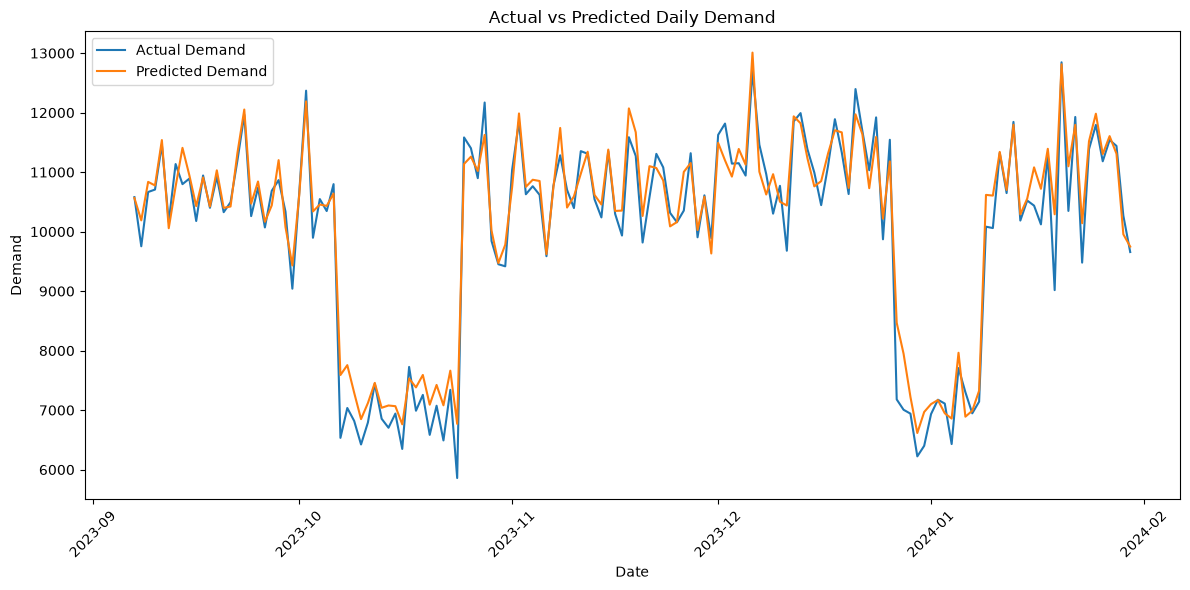


TOP 15 MODEL FEATURES
                    Feature  Importance
13         Demand_Rolling_7    0.330334
1                     Price    0.121321
3                 Promotion    0.112317
5                  Epidemic    0.041990
4        Competitor Pricing    0.039301
40       Category_Groceries    0.032695
47  Weather Condition_Sunny    0.029701
39       Category_Furniture    0.026945
14        Demand_Rolling_28    0.024397
0           Inventory Level    0.021085
10             Demand_Lag_1    0.017817
49       Seasonality_Summer    0.017742
11             Demand_Lag_7    0.017118
12            Demand_Lag_28    0.017002
2                  Discount    0.012523


<Figure size 1000x700 with 0 Axes>

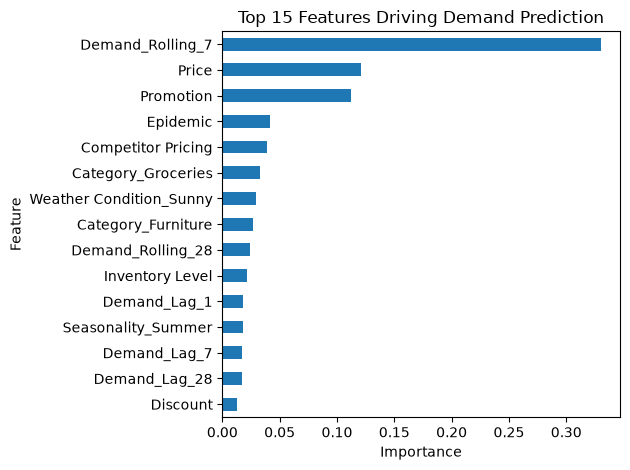


PROJECT COMPLETED
Charts saved in: ./charts/
Predictions saved as: demand_predictions.csv
Product summary saved as: product_summary.csv


In [ ]:
# Corrected continuation after the model evaluation step
prediction_df = df.loc[
    test.index,
    ["Date", "Store ID", "Product ID", "Demand"]
].copy()

prediction_df["Predicted Demand"] = y_pred

daily_prediction = (
    prediction_df
    .groupby("Date")
    .agg(
        Actual_Demand=("Demand", "sum"),
        Predicted_Demand=("Predicted Demand", "sum")
    )
    .reset_index()
 )

plt.figure(figsize=(12, 6))
plt.plot(
    daily_prediction["Date"],
    daily_prediction["Actual_Demand"],
    label="Actual Demand"
 )
plt.plot(
    daily_prediction["Date"],
    daily_prediction["Predicted_Demand"],
    label="Predicted Demand"
 )
plt.title("Actual vs Predicted Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/10_actual_vs_predicted.png", dpi=150)
plt.show()

feature_importance = (
    pd.DataFrame({
        "Feature": encoded_features,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(15)
 )

print("\n" + "=" * 60)
print("TOP 15 MODEL FEATURES")
print("=" * 60)
print(feature_importance)

plt.figure(figsize=(10, 7))
feature_importance.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
 )
plt.title("Top 15 Features Driving Demand Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("charts/11_feature_importance.png", dpi=150)
plt.show()

prediction_df.to_csv("demand_predictions.csv", index=False)
product_summary.to_csv("product_summary.csv")

print("\n" + "=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)
print("Charts saved in: ./charts/")
print("Predictions saved as: demand_predictions.csv")
print("Product summary saved as: product_summary.csv")

In [ ]:
import os

# ==============================
# CREATE PROJECT FOLDER STRUCTURE
# ==============================

# Lấy folder hiện tại của project
PROJECT_DIR = os.getcwd()

# Các folder cần tạo
folders = [
    "data",
    "notebooks",
    "outputs",
    "charts"
]

# Tạo folders
for folder in folders:
    path = os.path.join(PROJECT_DIR, folder)
    os.makedirs(path, exist_ok=True)

print("Project structure created successfully!")
print()
print(PROJECT_DIR)
print()
print("Folders:")
for folder in folders:
    print(f"├── {folder}/")

Project structure created successfully!

c:\Users\Admin\Desktop\DA projects\Retail, Inventory, Demand prediction

Folders:
├── data/
├── notebooks/
├── outputs/
├── charts/


In [ ]:
import shutil
import os

source = os.path.join(PROJECT_DIR, "data", "sales_data.csv")
destination = os.path.join(PROJECT_DIR, "data", "sales_data.csv")

if os.path.exists(source):
    shutil.move(source, destination)
    print("sales_data.csv moved to data/")
else:
    print("sales_data.csv not found in project folder.")
    

sales_data.csv moved to data/
